<div style="font-size:80%">

# Peri-Stimulus Time Histogram (PSTH)

## 概要

**Peri-Stimulus Time Histogram（PSTH）** は、神経活動（スパイク）を外的イベント（刺激提示や行動など）に時間整列し、イベント前後の平均的な発火率を可視化・定量化する解析手法である。多くの試行にわたるスパイク時刻を一定の時間幅でビン分割し、イベント時刻との相対時間でヒストグラムを作成することで、神経応答の時間構造を明らかにする。

---

## 計算手順

1. **スパイク時刻の取得**  
   全試行における神経スパイク発火時刻を `spike_times` に格納する。

2. **イベント時刻の指定**  
   各試行の基準イベント（例：刺激提示）時刻を `event_times` に指定する。

3. **整列処理（アラインメント）**  
   各イベントに対しスパイク時刻を整列（`spike_times - event_time`）し、指定された時間窓内（例：-0.5秒〜+1.0秒）のスパイクを抽出する。

4. **ビン分割とスパイクカウント**  
   ビン幅 `bin_size`（例：10 ms）で時間軸を分割し、各ビンに入るスパイク数をヒストグラムでカウントする。

5. **平均発火率への変換**  
   試行数で割り、1試行あたりの平均スパイク発火率（Hz）に変換する：

$$
\text{PSTH}_{\text{Hz}} = \frac{\text{Spike Count}}{\text{Number of Trials} \times \text{Bin Width}}
$$



---

## パラメータの説明

| 変数名       | 内容                                                                 |
|------------|----------------------------------------------------------------------|
| `bin_size` | ビン幅（秒）。例：`0.01` は 10ms ごとのスパイクカウント。           |
| `window`   | 時間窓（秒）。例：`[-0.5, 1.0]` は刺激前0.5秒〜後1.0秒を対象にする。  |
| `spike_times` | スパイク発火時刻（ランダムに生成）。実験データに置き換える。     |
| `event_times` | イベント時刻（例：刺激提示）。これを基準にスパイクを整列する。    |

---

## 解釈と応用

- PSTH は、特定のイベントに対する神経応答の**時間的変化**を明確にする。
- 明確なピークは、**一過性かつ一貫した応答**を示す。
- 持続的な活動や応答の欠如も可視化可能。
- シングルユニットやマルチユニット、光遺伝学刺激など多様な解析に利用される。

---

## 注意点

- **ビン幅**は時間分解能とノイズのトレードオフを調整する。
- **試行数**が少ないと平均化の信頼性が低くなる。
- 統計的有意性を検定するには、ベースラインとの比較が必要。

---

## 参考文献

- Gerstein, G. L., & Perkel, D. H. (1969). *Simultaneously recorded trains of action potentials: analysis and functional interpretation*. Science, 164(3881), 828–830.
- Dayan, P., & Abbott, L. F. (2001). *Theoretical Neuroscience*. MIT Press.
- https://www.tdt.com/docs/sdk/offline-data-analysis/offline-data-python/examples/03_RasterPSTH/

<br>
<br>
<br>

---

# PETH(Peri-Event Time Histogram) 
- 刺激だけではなく、行動も含めた意味でPeri-Event Time Histgramということもある。
- 今回はPETHとして関数を作成している。
- 関数の説明は以下

入力

| 変数名                    | 型                      | 説明                                                                  |
| ---------------------- | ---------------------- | ------------------------------------------------------------------- |
| `spike_times`          | `np.ndarray`           | 全スパイク時刻の配列（単位：秒）。すべてのトライアルを通したスパイク。                                 |
| `event_times`          | `np.ndarray`           | 各試行の基準イベント（刺激等）の時刻（単位：秒）。                                           |
| `bin_size`             | `float`                | PSTHのビン幅（単位：秒）。例：0.05なら50 msごとにスパイクを数える。                            |
| `time_window`          | `list[float, float]`   | 各イベント前後の解析時間範囲（例：\[-1, 1] は -1秒から+1秒）。                              |



出力



| 変数名                    | 型                      | 説明                                                                  |
| ---------------------- | ---------------------- | ------------------------------------------------------------------- |
| `peth['trial']`        | `np.ndarray[int]`      | トライアル番号の配列（1, 2, ..., n\_trials）。                                   |
| `peth['bins']`         | `np.ndarray[float]`    | ビンの境界配列（時間軸用）。                                                      |
| `peth['spike_counts']` | `np.ndarray[np.uint8]` | 各トライアル・ビンごとのスパイク数（符号なし8bit整数）。                                      |

</div>

In [1]:
# Basic
import os
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns
import csv
import pickle

# SpikeInterface
import spikeinterface as si
import spikeinterface.extractors as se
from spikeinterface.preprocessing import get_motion_parameters_preset, get_motion_presets

# Local imports
import libs.utils.utils as utils
import libs.handle.dataset as dataset
import libs.analysis.spikes as spikes

c:\Users\shoya\code\tamagawa-neuro-training-shysgmt\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [19]:
def compute_behv_time(trials, event, procTeensy_to_imec): 
 
    event_grouped = event.groupby('trial') 
    target_trials = trials['trial'].dropna().astype(int).values 
 
    ready_time = np.zeros(len(target_trials)) 
    stim_time = np.zeros(len(target_trials)) 
    choice_time = np.zeros(len(target_trials)) 
    outcome_time = np.zeros(len(target_trials)) 
 
    for i in range(len(target_trials)): 
 
        df = event_grouped.get_group(target_trials[i]) 
         
        tf = (df['state'].isin([3, 4])) & (df['state'].shift(1).isin([2])) 
        row = df[tf]['row_index'].values 
        ready_time[i] = procTeensy_to_imec[row[0]] 
         
        tf = (
            df['state'].isin([3, 4])
            & df['column_name_changed'].isin(['binary_photodiode'])
        )
        row = df[tf]['row_index'].values 
        stim_time[i] = procTeensy_to_imec[row[0]] 
 
        tf = (
            df['state'].isin([5, 6, 7, 8])
            & df['state'].shift(1).isin([3, 4])
        )
        row = df[tf]['row_index'].values 
        choice_time[i] = procTeensy_to_imec[row[0]] 
         
        tf = (
            df['column_name_changed'].isin(['dispenser'])
            & (df['dispenser'] == 1)
        )
        
        if tf.any(): 
            row = df[tf]['row_index'].values 
            outcome_time[i] = procTeensy_to_imec[row[0]] 
        else: 
            outcome_time[i] = np.nan 
         
    behavior_time = { 
        'trial': target_trials, 
        'ready': ready_time, 
        'stim': stim_time, 
        'choice': choice_time, 
        'outcome': outcome_time 
    } 
         
    return behavior_time



# Compute PETH dict
# spike_time, event_timeなどから、peth_fr, petf_drを計算してまとめる関数
def compute_peth_dict(spike_time, event_time, bin_size=0.05, time_window=[-1, 1.5], sigma_sec=0.05):
    peth = spikes.compute_peth_array(
    spike_times=spike_time,
        event_times=event_time,
        bin_size=bin_size,
        time_window=time_window)

    peth_smooth = spikes.compute_peth_smooth(peth, sigma_sec=sigma_sec)
    peth_fr = spikes.compute_peth_fr(peth_smooth)
    peth_df = spikes.peth_to_longdf(peth_fr)
    
    PETH = {
        'fr': peth_fr,
        'df': peth_df
    }
    
    return PETH


# Function to compute z-score from PETH DataFrame
def compute_base_line(PETH, target_time_window=[0, 1]):
    df = PETH['df']
    avg = df.loc[(df['time']>=target_time_window[0]) & (df['time']<target_time_window[1]), 'spike_rate'].mean()
    std = df.loc[(df['time']>=target_time_window[0]) & (df['time']<target_time_window[1]), 'spike_rate'].std()
    base_line = {
        'avg': avg,
        'std': std
    }
    return base_line


# Function to compute z-score from PETH DataFrame
def compute_z_score(PETH, target_time_window=[0, 1], base_line=[0, 1]):
    fr = PETH['fr']
    bins = fr['bins']
    z_score = (fr['spike_rate'] - base_line['avg']) / base_line['std']
    # Filter
    tf = (bins[0:-1]>=target_time_window[0])&(bins[0:-1]<target_time_window[1])
    z_score_target = z_score[:, tf]
    mean_z_score = z_score_target.mean(axis=0)
    return mean_z_score

In [3]:
# Generate a session object
session_dir = r"D:\data\RSS060_260817_164455"
session = dataset.Session(session_dir)

In [4]:
# Extract dataset of target probe
i_imec = 0
session.add_trials()
session.add_event()
session.add_sorting_analyzer(i_imec=i_imec)
session.add_procTeensy_to_imec(i_imec=i_imec)


Loading sorting_analyzer from D:\data\RSS060_260817_164455\spikeinterface\imec0\sorting_analyzer_dredge


In [5]:
trials = session.trials
event = session.event

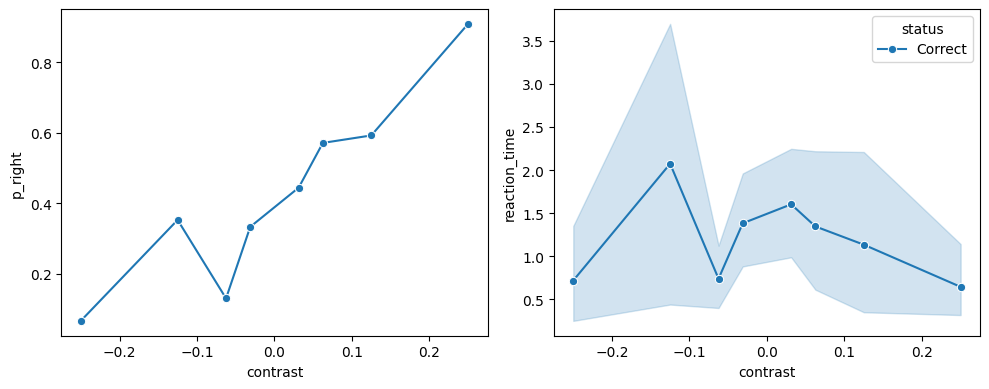

In [20]:
df = trials.copy()
df['pushsum'] = df['pc_left']+df['pc_right']
df['p_right'] = df['choice'].map({'left': 0, 'right': 1})

df['reaction_time'] = np.where(
    df['choice'] == 'left',
    df['rt_left'],
    df['rt_right']
)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.lineplot(
    data=df,
    x='contrast',
    y='p_right',
    marker='o',
    errorbar=None,
)

plt.subplot(1, 2, 2)
df = df[df['pushsum']==1]
df = df[df['status']=='Correct']
sns.lineplot(
    data=df,
    x='contrast',
    y='reaction_time',
    hue='status',
    marker='o',
)

plt.tight_layout()

In [ ]:
# Extract sorting data
sorting = session.sorting_analyzer.sorting

# Select units labeled as "good" by Kilosort
ks_label = sorting.get_property('KSLabel')
good_unit_ids = sorting.unit_ids[ks_label == 'good']

# Create a sorting object containing only good units
sorting = sorting.select_units(good_unit_ids)

In [61]:
unit_ids = sorting.get_unit_ids()
procTeensy_to_imec = session.procTeensy_to_imec
sampling_rate = sorting.sampling_frequency
behv_time = compute_behv_time(trials, event, procTeensy_to_imec) 

In [62]:
unit_ids

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
       117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
       130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
       143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155,
       156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168,
       169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 18

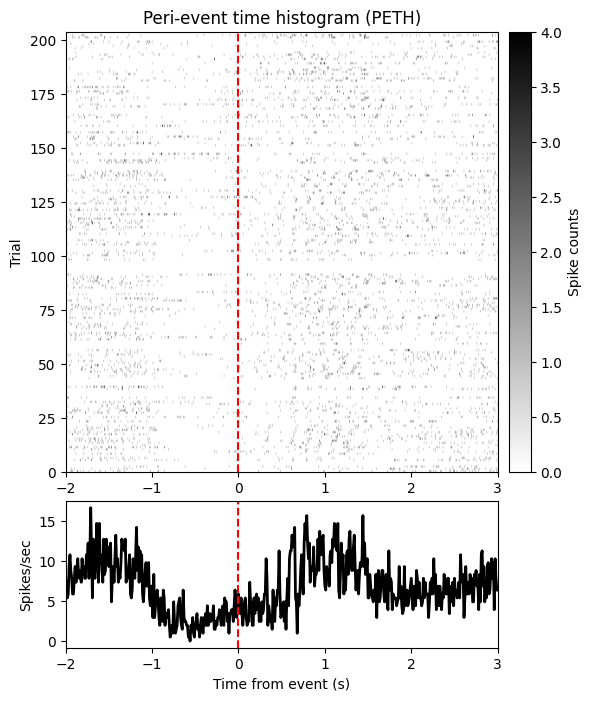

In [66]:
unit_id = unit_ids[2]
# unit_id = 98
event_time = behv_time['outcome']
spike_time = sorting.get_unit_spike_train(unit_id=unit_id)/sampling_rate

peth = spikes.compute_peth_array(
    spike_times=spike_time,
    event_times=event_time,
    bin_size=0.01,
    time_window=[-2, 3])

#print('Trials', len(peth['trial']))
#print(peth['trial'])
#print('Bins', len(peth['bins']))
#print(peth['bins'])
#print('Spike counts', np.shape(peth['spike_counts']))
#print(peth['spike_counts'])

spikes.plot_peth(peth)

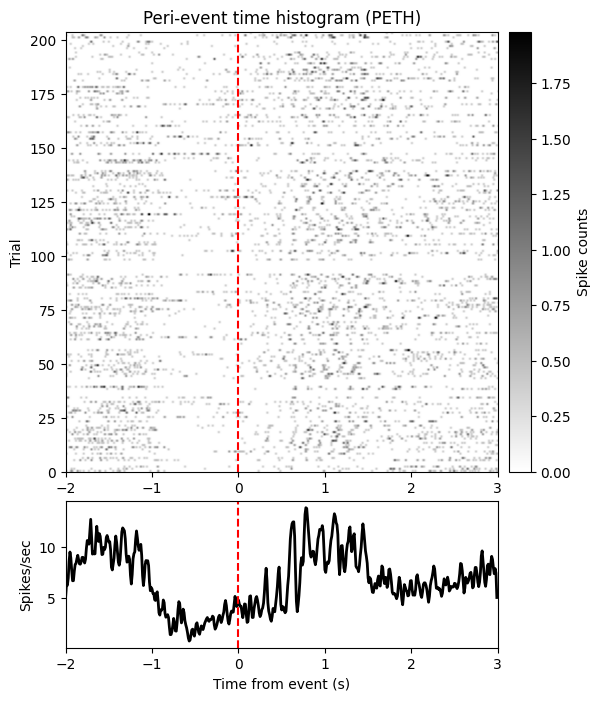

In [11]:
peth_smooth = spikes.compute_peth_smooth(peth, sigma_sec=0.01)
spikes.plot_peth(peth_smooth)

(-1.0, 2.0)

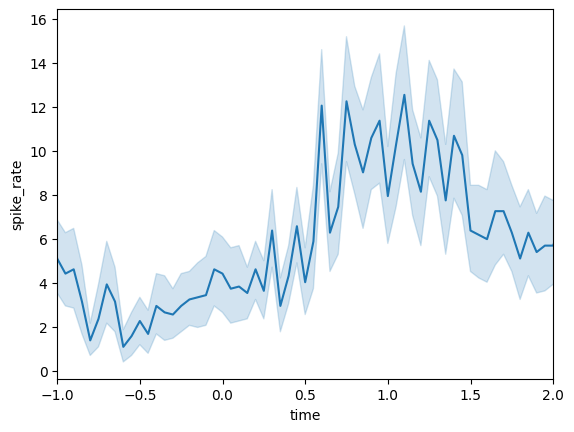

In [12]:
unit_id = unit_ids[2]
event_time = behv_time['outcome']
spike_time = sorting.get_unit_spike_train(unit_id=unit_id)/sampling_rate

peth = spikes.compute_peth_array(
    spike_times=spike_time,
    event_times=event_time,
    bin_size=0.05,
    time_window=[-2, 3])

peth_smooth = spikes.compute_peth_smooth(peth, sigma_sec=0.01)
peth_fr = spikes.compute_peth_fr(peth_smooth)

peth_df = spikes.peth_to_longdf(peth_fr)

sns.lineplot(
    data=peth_df, 
    x='time', 
    y='spike_rate', 
)
plt.xlim([-1, 2])

In [21]:
trial_target = trials[['trial', 'stim', 'choice', 'correct']].dropna()
df = peth_df.merge(trial_target, on='trial', how='left')
df

,time,trial,spike_rate,stim,choice,correct
0,-2.00,1,0.000000,right,right,True
1,-1.95,1,0.000000,right,right,True
2,-1.90,1,0.000000,right,right,True
3,-1.85,1,0.000000,right,right,True
4,-1.80,1,0.000000,right,right,True
...,...,...,...,...,...,...
20395,2.75,204,16.334384,left,left,True
20396,2.80,204,13.275551,left,left,True
20397,2.85,204,20.991185,left,left,True
20398,2.90,204,30.567339,left,left,True


(-1.0, 3.0)

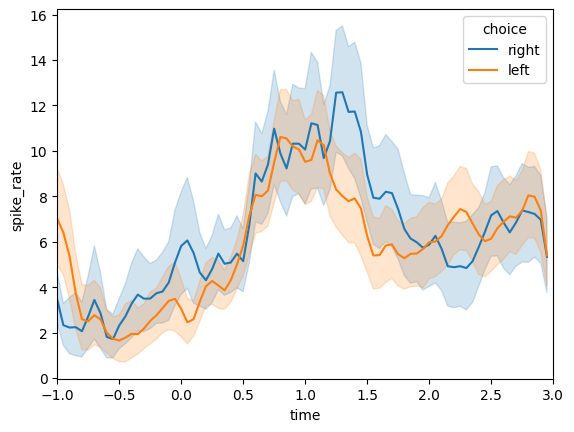

In [22]:
 #Long-formatはseabornと相性がいい。
sns.lineplot(
    data=df, 
    x='time', 
    y='spike_rate',
    hue='choice',
)
plt.xlim([-1, 3])

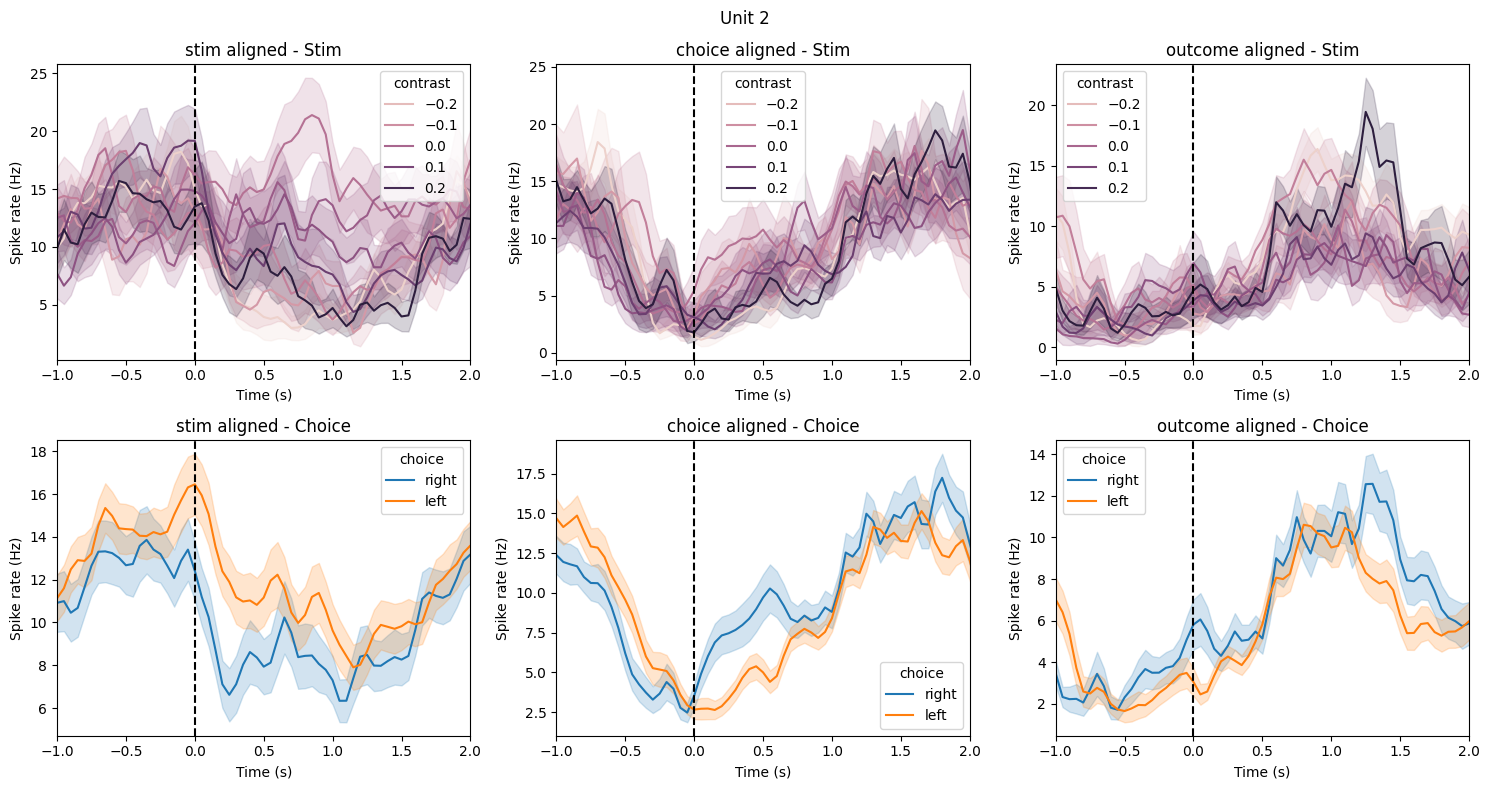

In [23]:
unit_id = unit_ids[2]
spike_time = sorting.get_unit_spike_train(unit_id=unit_id) / sampling_rate

events = {
    'stim': behv_time['stim'],
    'choice': behv_time['choice'],
    'outcome': behv_time['outcome']
}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for j, (event_name, event_time) in enumerate(events.items()):

    peth = spikes.compute_peth_array(
        spike_times=spike_time,
        event_times=event_time,
        bin_size=0.05,
        time_window=[-2, 3]
    )

    peth_smooth = spikes.compute_peth_smooth(peth, sigma_sec=0.05)
    peth_fr = spikes.compute_peth_fr(peth_smooth)
    peth_df = spikes.peth_to_longdf(peth_fr)

    trial_target = trials[['trial', 'stim', 'contrast', 'choice', 'correct']].dropna()
    df = peth_df.merge(trial_target, on='trial', how='left')

    # Split by stimulus
    sns.lineplot(
        data=df,
        x='time',
        y='spike_rate',
        hue='contrast',
        errorbar='se',
        ax=axes[0, j]
    )
    axes[0, j].set_title(f'{event_name} aligned - Stim')

    # Split by choice
    sns.lineplot(
        data=df,
        x='time',
        y='spike_rate',
        hue='choice',
        errorbar='se',
        ax=axes[1, j]
    )
    axes[1, j].set_title(f'{event_name} aligned - Choice')

for ax in axes.flat:
    ax.set_xlim([-1, 2])
    ax.axvline(0, color='k', linestyle='--')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Spike rate (Hz)')

plt.suptitle(f'Unit {unit_id}')
plt.tight_layout()
plt.show()

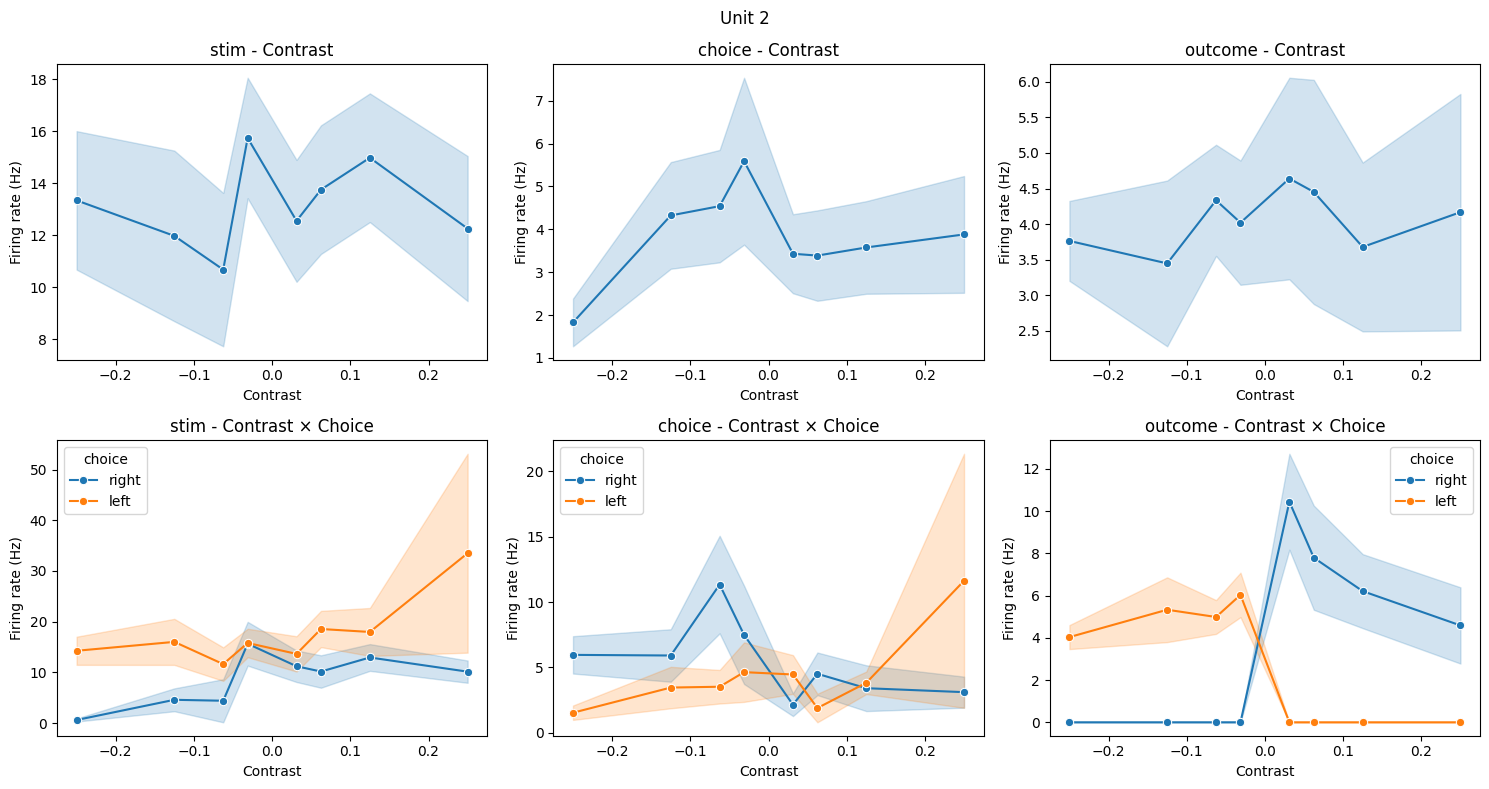

In [24]:
unit_id = unit_ids[2]
spike_time = sorting.get_unit_spike_train(unit_id=unit_id) / sampling_rate

events = {
    'stim': (behv_time['stim'], [0, 0.2]),
    'choice': (behv_time['choice'], [-0.2, 0.2]),
    'outcome': (behv_time['outcome'], [0, 0.3])
}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for j, (event_name, (event_time, fr_window)) in enumerate(events.items()):
    peth = spikes.compute_peth_array(
        spike_times=spike_time,
        event_times=event_time,
        bin_size=0.05,
        time_window=[-1, 1]
    )

    peth_smooth = spikes.compute_peth_smooth(peth, sigma_sec=0.05)
    peth_fr = spikes.compute_peth_fr(peth_smooth)

    bins = peth_fr['bins'][:-1]
    fr = peth_fr['spike_rate']

    # Mean FR for each trial
    tf = (bins >= fr_window[0]) & (bins < fr_window[1])
    trial_fr = fr[:, tf].mean(axis=1)

    df = trials[['trial', 'contrast', 'choice', 'correct']].copy()
    df['fr'] = trial_fr

    sns.lineplot(
        data=df,
        x='contrast',
        y='fr',
        marker='o',
        errorbar='se',
        ax=axes[0, j]
    )
    axes[0, j].set_title(f'{event_name} - Contrast')

    sns.lineplot(
        data=df,
        x='contrast',
        y='fr',
        hue='choice',
        marker='o',
        errorbar='se',
        ax=axes[1, j]
    )
    axes[1, j].set_title(f'{event_name} - Contrast × Choice')

for ax in axes.flat:
    ax.set_xlabel('Contrast')
    ax.set_ylabel('Firing rate (Hz)')

plt.suptitle(f'Unit {unit_id}')
plt.tight_layout()
plt.show()

<div style="font-size:80%">

## Z-score

### 定義
Z-score は、あるデータ点が平均からどれだけ離れているかを **標準偏差の単位で表す**統計量です。

\[
z = \frac{x - \mu}{\sigma}
\]

- \( x \)：観測値  
- \( \mu \)：全体の平均  
- \( \sigma \)：標準偏差  

---

### 意味と解釈
- \( z = 0 \)：平均と等しい  
- \( z = 1 \)：平均より 1 標準偏差上  
- \( z = -2 \)：平均より 2 標準偏差下  

---

### 用途
- 異なるスケールのデータを標準化して比較する  
- 異常値（アウトライヤー）の検出  
- 正規分布に従うデータの確率評価  
- 神経活動のベースラインと刺激後の比較に使用（例：PETH）

---

### 神経科学での例
スパイク発火率の時間変化において、ベースライン(例：刺激提示前)の平均と標準偏差をもとに、刺激後の活動の変化を Z-score で評価：

```python
z = (spike_rate - baseline_mean) / baseline_std
```

Z-score によって、神経活動の有意な変化を定量的に評価可能になります。

</div>

Baseline average spike rate: 10.642088796622131
Baseline standard deviation of spike rate: 14.054125468347204


Text(0, 0.5, 'Z-score of Spike Rate')

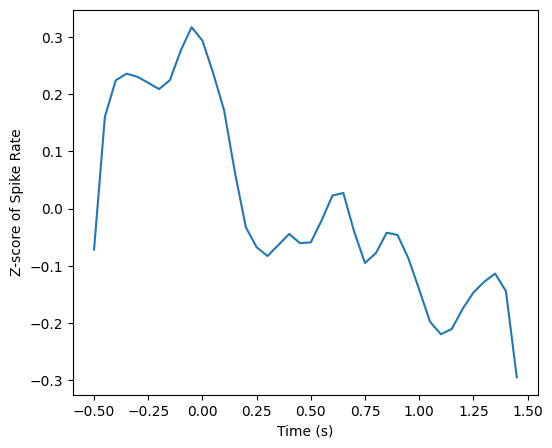

In [17]:
# Compute z-score of spike rate
unit_id = unit_ids[2]
spike_time = sorting.get_unit_spike_train(unit_id=unit_id)/sampling_rate

bin_size = 0.05
sigma_sec = 0.05
PETH = compute_peth_dict(spike_time, behv_time['stim'], bin_size=bin_size, time_window=[-0.5, 1.5], sigma_sec=sigma_sec)
df = PETH['df']

avg = df.loc[(df['time']>=0) & (df['time']<1), 'spike_rate'].mean()
std = df.loc[(df['time']>=0) & (df['time']<1), 'spike_rate'].std()
base_line = {
    'avg': avg,
    'std': std
}
print('Baseline average spike rate:', avg)
print('Baseline standard deviation of spike rate:', std)

fr = PETH['fr']
bins = fr['bins']
spks = fr['spike_rate']
z_score = (spks - base_line['avg']) / base_line['std']

plt.figure(figsize=(6, 5))
sns.lineplot(
    x=bins[0:-1],
    y=z_score.mean(axis=0),
)
plt.xlabel('Time (s)')
plt.ylabel('Z-score of Spike Rate')

<div style="font-size:80%">

# 神経活動に基づくニューロンのクラスタリング

---

## クラスタリングとは？

神経活動に基づくクラスタリングとは、**スパイク発火パターンや応答特性が似ているニューロン同士を自動的にグループ分けする**手法です。  
これは、**神経回路の機能的構造や役割を理解する**うえで重要な解析です。

---

## 一般的な流れ

### 1. **特徴抽出（Feature Extraction）**

各ニューロンについて、以下のような特徴量を数値化します：

- 発火率（firing rate）
- PSTH / PETH（刺激に対する時間的発火パターン）
- チューニング特性（例：方向選好性、感覚応答強度）
- スパイク波形や応答遅延

→ 各ニューロンを高次元ベクトルとして表現します。

---

### 2. **次元削減（Dimensionality Reduction）※任意**

視覚化やクラスタ分離のために、次元を2〜3次元に圧縮します：

- PCA（主成分分析）
- t-SNE
- UMAP など

---

### 3. **クラスタリング（Clustering）**

教師なし学習アルゴリズムで類似ニューロンを自動分類します：

- K-means
- 階層クラスタリング
- Gaussian Mixture Models（GMM）
- DBSCAN（密度に基づくクラスタリング）

---

### 4. **クラスタの解釈**

各クラスタが何を意味するのかを評価します：

- 刺激応答の違い（例：視覚 vs 聴覚）
- 動作準備 vs 実行などの機能的分化
- 脳領域やレイヤーとの対応
- 学習や注意状態による変化

---

## なぜクラスタリングするのか？

- **機能的ニューロンタイプの識別**（例：選好性のある vs ない細胞）
- **神経集団の構造把握**やパターン発見
- **状態変化や学習効果の評価**
- データの次元圧縮と可視化

---

## 補足

この手法は「教師なし学習（unsupervised learning）」の一例であり、**あらかじめ正解ラベルが存在しない**データの構造を明らかにする目的で使われます。

スパイク列だけでなく、**カルシウムイメージングやfMRIなど他の神経データ**にも応用可能です。

</div>

In [ ]:
unit_id = unit_ids[100]
spike_time = sorting.get_unit_spike_train(unit_id=unit_id)/sampling_rate
bin_size=0.05
sigma_sec=0.05

event_time = behv_time['stim']
PETH = compute_peth_dict(spike_time, event_time, bin_size=bin_size, time_window=[-0.5, 1.5], sigma_sec=sigma_sec)
base_line = compute_base_line(PETH=PETH, target_time_window=[0, 1])

event_time = behv_time['choice']
PETH = compute_peth_dict(spike_time, event_time, bin_size=0.05, time_window=[-0.5, 1.5], sigma_sec=sigma_sec)
mean_z_socre = compute_z_score(PETH=PETH, target_time_window=[0, 1], base_line=base_line)

In [26]:
bin_size = 0.05
sigma_sec = 0.01

# Initialize arrays with event-specific bin lengths
z_score_stim = np.zeros((len(unit_ids), 4))
z_score_choice = np.zeros((len(unit_ids), 8))
z_score_outcome = np.zeros((len(unit_ids), 10))

# Compute z-score for each unit and event type
for i in range(len(unit_ids)):
    unit_id = unit_ids[i]
    spike_time = sorting.get_unit_spike_train(unit_id=unit_id) / sampling_rate

    # Baseline
    event_time = behv_time['ready']
    PETH = compute_peth_dict(
        spike_time, event_time,
        bin_size=bin_size,
        time_window=[-0.5, 1.5],
        sigma_sec=sigma_sec
    )
    base_line = compute_base_line(PETH=PETH, target_time_window=[0, 1])

    # Stim
    event_time = behv_time['stim']
    PETH = compute_peth_dict(
        spike_time, event_time,
        bin_size=bin_size,
        time_window=[-0.5, 1],
        sigma_sec=sigma_sec
    )
    z_score_stim[i, :] = compute_z_score(
        PETH=PETH,
        target_time_window=[0, 0.2],
        base_line=base_line
    )

    # Choice
    event_time = behv_time['choice']
    PETH = compute_peth_dict(
        spike_time, event_time,
        bin_size=bin_size,
        time_window=[-0.5, 1],
        sigma_sec=sigma_sec
    )
    z_score_choice[i, :] = compute_z_score(
        PETH=PETH,
        target_time_window=[-0.2, 0.2],
        base_line=base_line
    )

    # Outcome
    event_time = behv_time['outcome']
    PETH = compute_peth_dict(
        spike_time, event_time,
        bin_size=bin_size,
        time_window=[-0.5, 1],
        sigma_sec=sigma_sec
    )
    z_score_outcome[i, :] = compute_z_score(
        PETH=PETH,
        target_time_window=[0, 0.5],
        base_line=base_line
    )

    if i % 10 == 0:
        print(f'Unit {i+1}/{len(unit_ids)}')

Unit 1/715
Unit 11/715
Unit 21/715
Unit 31/715
Unit 41/715
Unit 51/715
Unit 61/715
Unit 71/715
Unit 81/715
Unit 91/715
Unit 101/715
Unit 111/715
Unit 121/715
Unit 131/715
Unit 141/715
Unit 151/715
Unit 161/715
Unit 171/715
Unit 181/715
Unit 191/715
Unit 201/715
Unit 211/715
Unit 221/715
Unit 231/715
Unit 241/715
Unit 251/715
Unit 261/715
Unit 271/715
Unit 281/715
Unit 291/715
Unit 301/715
Unit 311/715
Unit 321/715
Unit 331/715
Unit 341/715
Unit 351/715
Unit 361/715
Unit 371/715
Unit 381/715
Unit 391/715
Unit 401/715
Unit 411/715
Unit 421/715
Unit 431/715
Unit 441/715
Unit 451/715
Unit 461/715
Unit 471/715
Unit 481/715
Unit 491/715
Unit 501/715
Unit 511/715
Unit 521/715
Unit 531/715
Unit 541/715
Unit 551/715
Unit 561/715
Unit 571/715
Unit 581/715
Unit 591/715
Unit 601/715
Unit 611/715
Unit 621/715
Unit 631/715
Unit 641/715
Unit 651/715
Unit 661/715
Unit 671/715
Unit 681/715
Unit 691/715
Unit 701/715
Unit 711/715


In [27]:
tunning_vector = np.concatenate(
    [z_score_stim, z_score_choice, z_score_outcome],
    axis=1
)

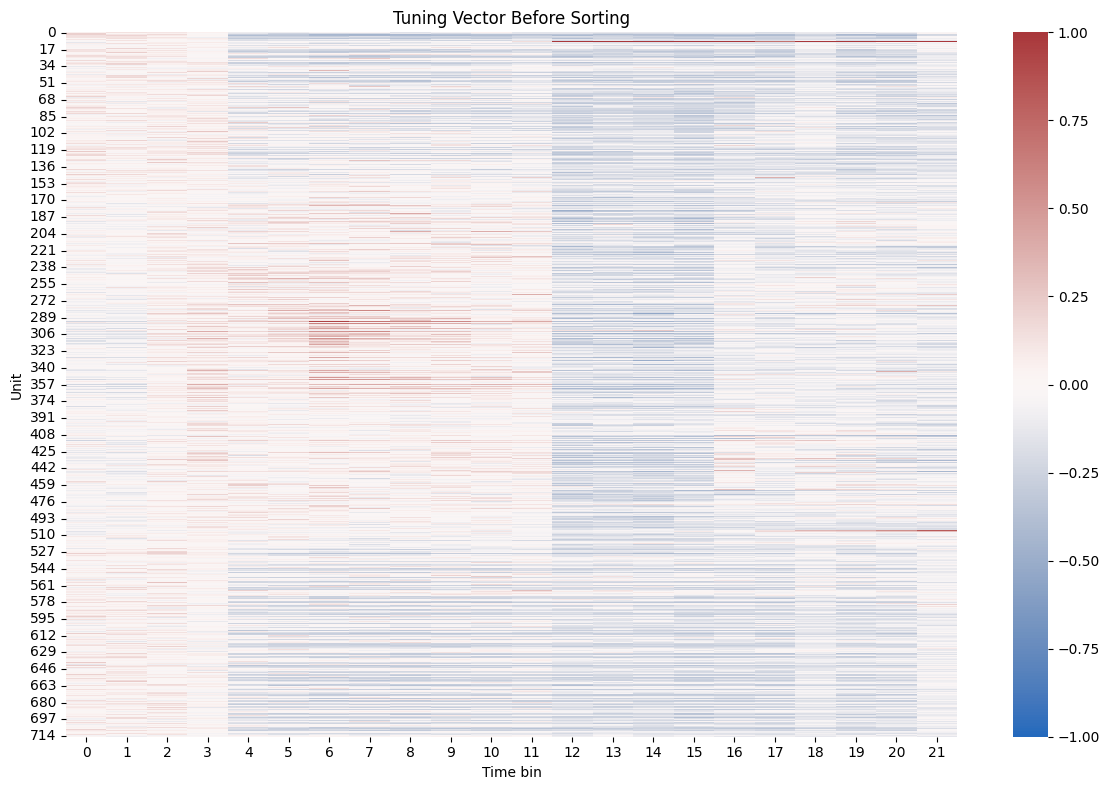

In [67]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    tunning_vector,
    cmap='vlag',
    center=0,
    vmin=-1,
    vmax=1,
)

plt.xlabel('Time bin')
plt.ylabel('Unit')
plt.title('Tuning Vector Before Sorting')
plt.tight_layout()
plt.show()

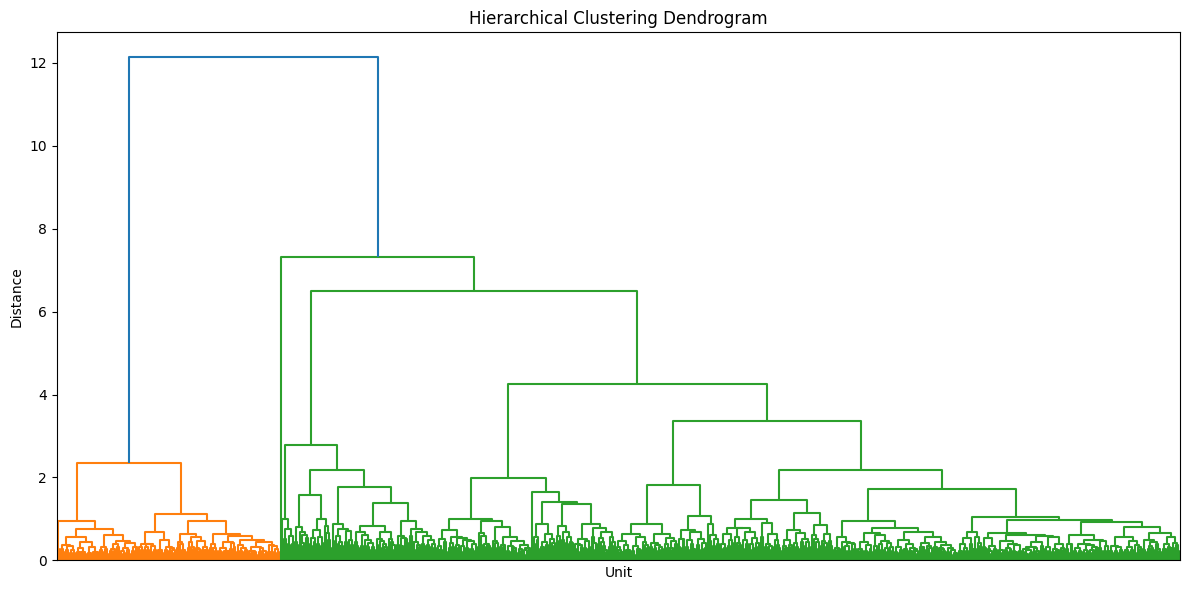

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

# Remove units containing NaN or extreme z-scores
z_threshold = 3

valid_mask = (
    ~np.isnan(tunning_vector).any(axis=1)
    & (np.abs(tunning_vector) <= z_threshold).all(axis=1)
)

tunning_vector_valid = tunning_vector[valid_mask]
unit_ids_valid = np.asarray(unit_ids)[valid_mask]

# PCA
n_components = min(20, tunning_vector_valid.shape[0], tunning_vector_valid.shape[1])
pca = PCA(n_components=n_components)
pca_result_valid = pca.fit_transform(tunning_vector_valid)

# Hierarchical clustering
Z = linkage(
    pca_result_valid,
    method='ward'
)

# Plot dendrogram first
plt.figure(figsize=(12, 6))
dendrogram(
    Z,
    no_labels=True
)

plt.xlabel('Unit')
plt.ylabel('Distance')
plt.title('Hierarchical Clustering Dendrogram')
plt.tight_layout()
plt.show()

In [69]:
# Define number of clusters based on the dendrogram
n_clusters = 10

cluster_labels_valid = fcluster(
    Z,
    t=n_clusters,
    criterion='maxclust'
)

# Restore cluster labels to original unit IDs
cluster_all = np.full(len(unit_ids), np.nan)
cluster_all[valid_mask] = cluster_labels_valid

df = pd.DataFrame({
    'UnitID': unit_ids,
    'Cluster': cluster_all
})

df

,UnitID,Cluster
0,0,7.0
1,1,2.0
2,2,1.0
3,3,1.0
4,4,1.0
...,...,...
710,710,9.0
711,711,2.0
712,712,7.0
713,713,9.0


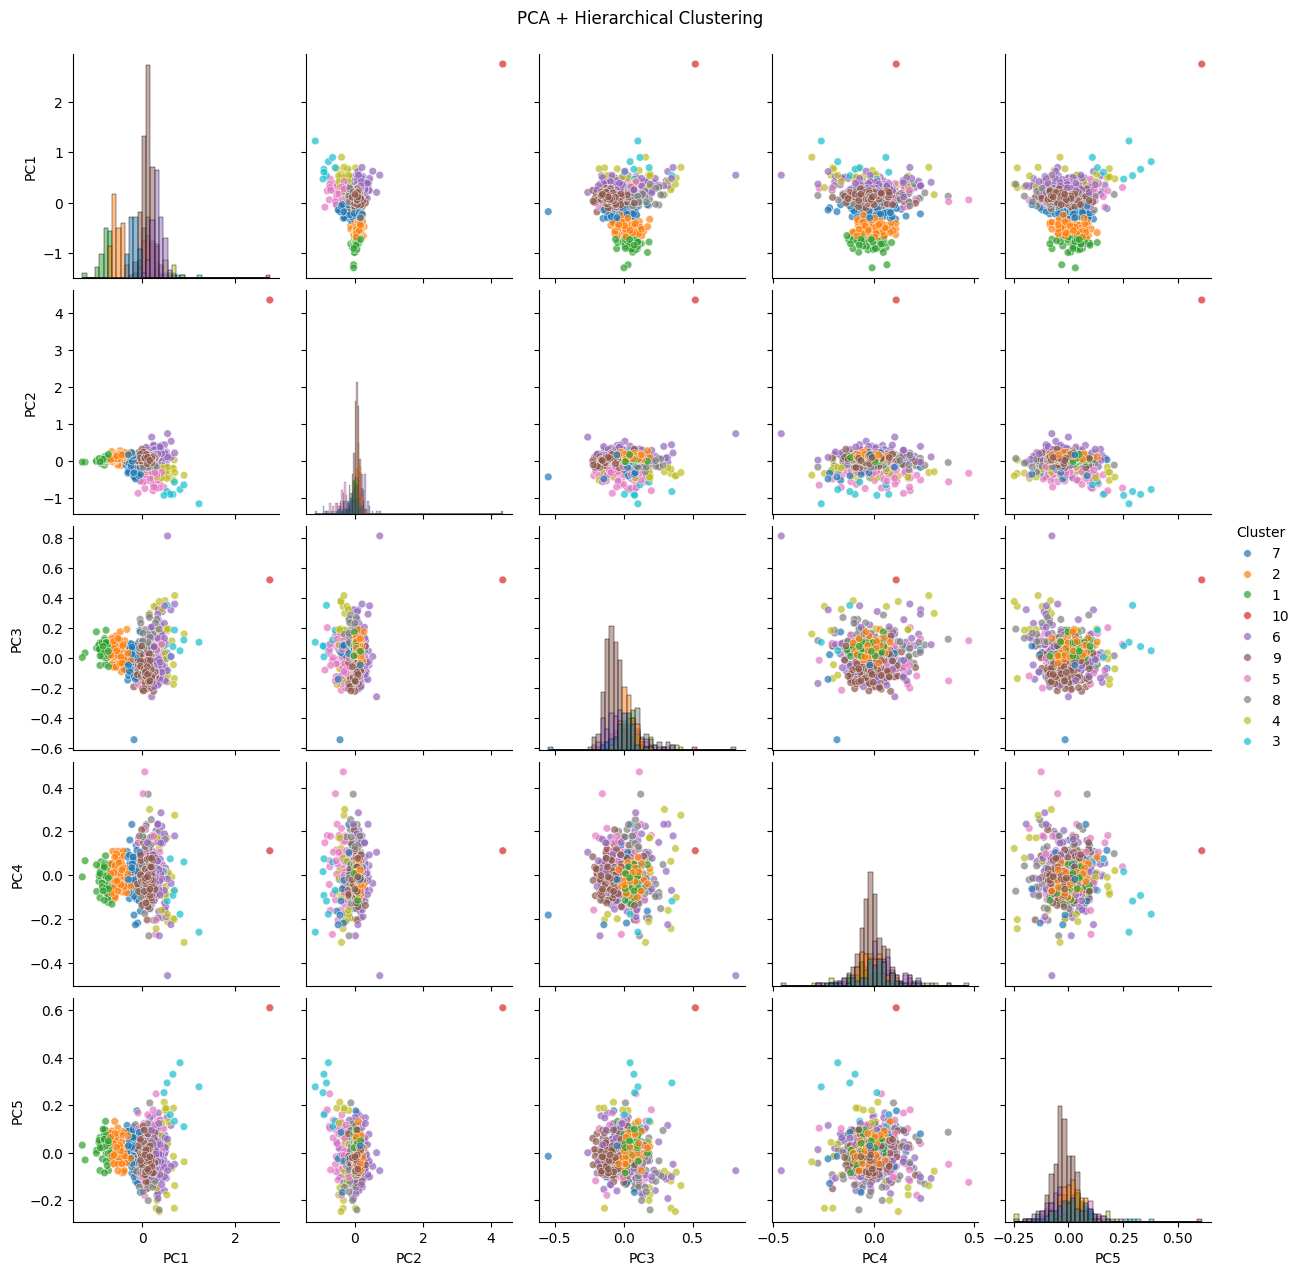

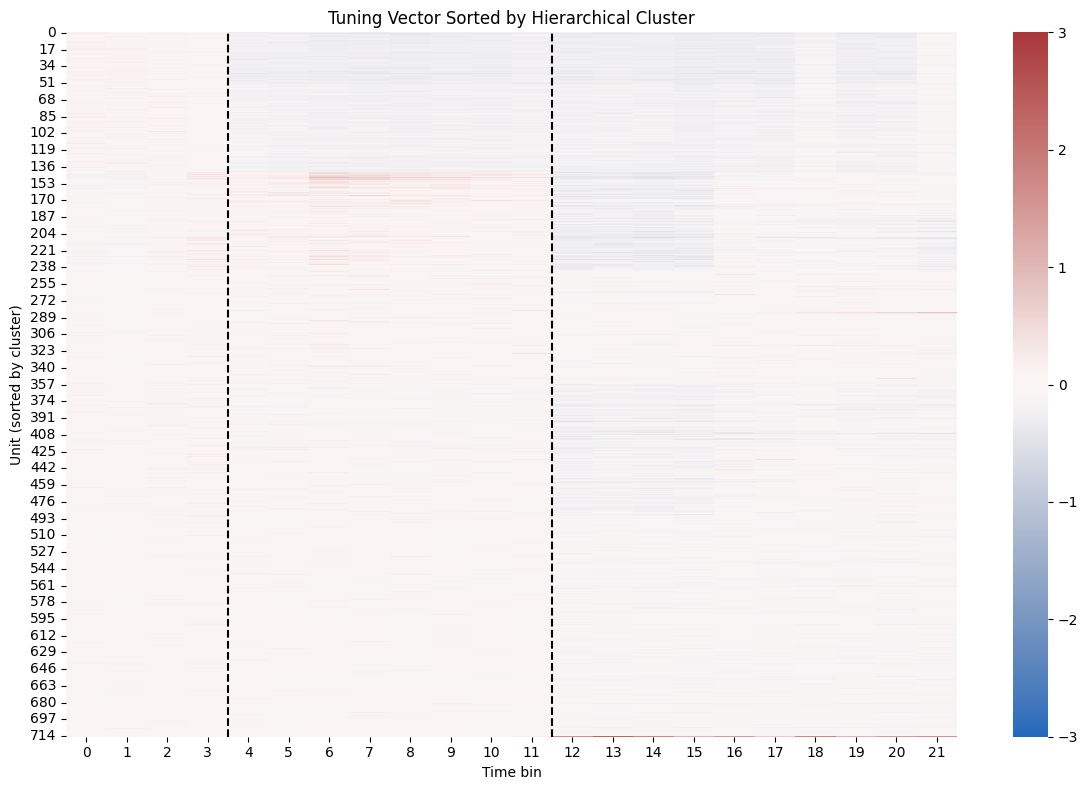

In [72]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create DataFrame from the first 5 PCA components
pca_info = pd.DataFrame(
    pca_result_valid[:, :5],
    columns=['PC1', 'PC2', 'PC3', 'PC4', 'PC5']
)

pca_info['Cluster'] = cluster_labels_valid.astype(str)
pca_info['UnitID'] = unit_ids_valid

# PCA pair plot
sns.pairplot(
    pca_info,
    vars=['PC1', 'PC2', 'PC3', 'PC4', 'PC5'],
    hue='Cluster',
    diag_kind='hist',
    plot_kws={'s': 30, 'alpha': 0.7}
)

plt.suptitle('PCA + Hierarchical Clustering', y=1.02)
plt.show()

# Sort units by cluster
sort_idx = np.argsort(cluster_labels_valid)
tunning_vector_sorted = tunning_vector_valid[sort_idx]

# Heatmap
plt.figure(figsize=(12, 8))

sns.heatmap(
    tunning_vector_sorted,
    cmap='vlag',
    center=0,
    vmin=-3,
    vmax=3
)

plt.axvline(4, color='k', linestyle='--')
plt.axvline(12, color='k', linestyle='--')

plt.xlabel('Time bin')
plt.ylabel('Unit (sorted by cluster)')
plt.title('Tuning Vector Sorted by Hierarchical Cluster')

plt.tight_layout()
plt.show()

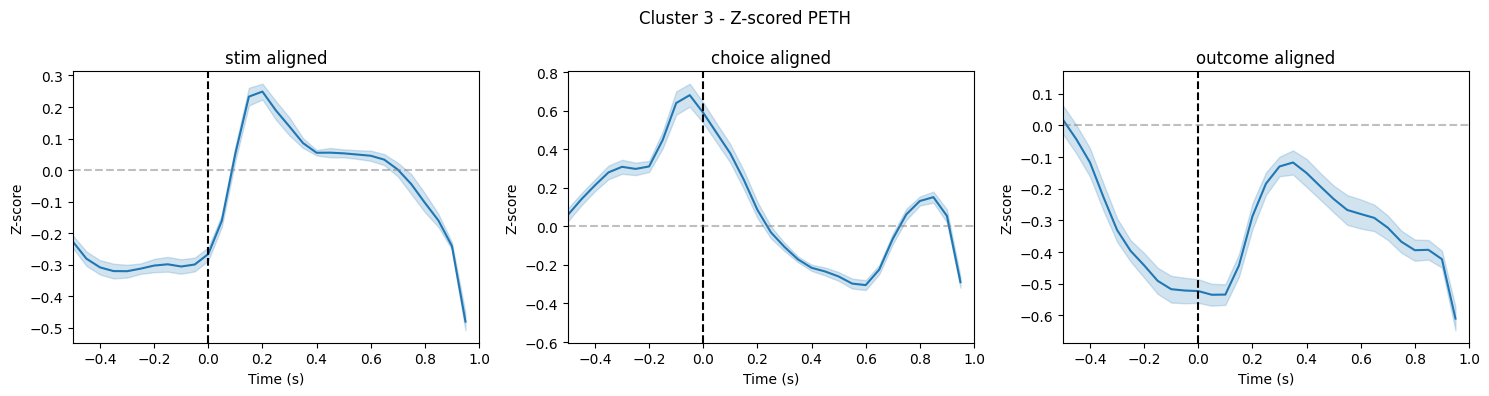

In [76]:
cluster_id = 3

# Units in this cluster
idx = np.where(cluster_labels_valid == cluster_id)[0]
cluster_unit_ids = unit_ids_valid[idx]

events = {
    'stim': behv_time['stim'],
    'choice': behv_time['choice'],
    'outcome': behv_time['outcome']
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for j, (event_name, event_time) in enumerate(events.items()):
    dfs = []

    for unit_id in cluster_unit_ids:
        spike_time = sorting.get_unit_spike_train(unit_id=unit_id) / sampling_rate

        # Compute baseline from ready period
        PETH_base = compute_peth_dict(
            spike_time,
            behv_time['ready'],
            bin_size=0.05,
            time_window=[-0.5, 1.5],
            sigma_sec=0.05
        )
        base_line = compute_base_line(
            PETH=PETH_base,
            target_time_window=[0, 1]
        )

        # Compute event PETH
        PETH = compute_peth_dict(
            spike_time,
            event_time,
            bin_size=0.05,
            time_window=[-1, 1],
            sigma_sec=0.05
        )

        fr = PETH['fr']
        bins = fr['bins'][:-1]

        # Z-score using ready baseline
        z_score = (
            fr['spike_rate'] - base_line['avg']
        ) / base_line['std']

        # Average across trials for each unit
        df_unit = pd.DataFrame({
            'time': bins,
            'z_score': np.nanmean(z_score, axis=0)
        })

        df_unit['unit_id'] = unit_id
        dfs.append(df_unit)

    df_cluster = pd.concat(dfs, ignore_index=True)

    sns.lineplot(
        data=df_cluster,
        x='time',
        y='z_score',
        errorbar='se',
        ax=axes[j]
    )

    axes[j].axvline(0, color='k', linestyle='--')
    axes[j].axhline(0, color='gray', linestyle='--', alpha=0.5)
    axes[j].set_title(f'{event_name} aligned')
    axes[j].set_xlabel('Time (s)')
    axes[j].set_ylabel('Z-score')
    axes[j].set_xlim([-0.5, 1])

plt.suptitle(f'Cluster {cluster_id} - Z-scored PETH')
plt.tight_layout()
plt.show()